### Data

Our data ([download link](https://drive.google.com/file/d/1ZWzmnIykk63pJuEBTonxbC4CBXJjI6t5/view?usp=sharing)) provides patient reviews on specific drugs and related conditions, and a 10-star rating reflecting overall patient satisfaction. The data was obtained by crawling online pharmaceutical review sites.

We will **build** and **train** a multilayer **CNN model** to predict if a review is positive (1) or negative (0).


<u>Note</u>: the original dataset is hosted by UCI - Machine Learning Repository [[Source]](https://archive.ics.uci.edu/ml/datasets/Drug+Review+Dataset+%28Drugs.com%29).

Import the necessary libraries and make sure to replace DATA_PATH with the path to the directories where you saved the data.

In [ ]:
#!pip install tensorflow

In [1]:
# standard
import pandas as pd
import numpy as np
import random
import os

# tf and keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence
from sklearn.preprocessing import LabelEncoder
import tensorflow_datasets as tfds

# plots and images
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image

# others
import re
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

#silence TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 


random.seed(2)
%matplotlib inline

# FILL IN CODE HERE #
DATA_PATH = '' # replace with your path

In [2]:
from platform import python_version

print(python_version())

3.11.9


In [3]:
def preprocessor(text):
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)',
                           text)
    text = (re.sub('[\W]+', ' ', text.lower()) +
            ' '.join(emoticons).replace('-', ''))
    return text

In [4]:
#!pip install latexify-py

In [5]:
# define function for token encoder
def encode(text_tensor, label):
    text = text_tensor.numpy()[0]
    encoded_text = encoder.encode(text)
    return encoded_text, label

#  wrap the encode function to a TF Operator
def encode_map_fn(text, label):
    return tf.py_function(encode, inp=[text, label], 
                          Tout=(tf.int64, tf.int64))

In [6]:
df_init = pd.read_csv('./data/drugs_raw.csv')
print('Number of reviews:', df_init.shape[0])
print('Reviews collected between:', df_init.date.min(), 'and ', df_init.date.max())
print('Unique rating values:', np.sort(df_init.rating.unique()))
df_init.head()

Number of reviews: 215063
Reviews collected between: April 1, 2008 and  September 9, 2017
Unique rating values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,"May 20, 2012",27
1,1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,"April 27, 2010",192
2,2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,"December 14, 2009",17
3,3,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,"November 3, 2015",10
4,4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,"November 27, 2016",37


In [7]:
# remove HTML markup, punctuation, and other non-letter characters
df_init['review'] = df_init['review'].apply(preprocessor)

We will define our sentiment column as follows:

   - positive (1) if rating score is between 8-10
   - negative (0) if rating score is between 1-3
    
We dill drop any reviews that are netural, i.e., rating is between 4-7.

In [8]:
# create sentiment column
df_init['sentiment'] = np.where(df_init.rating.isin((1, 2, 3)), 'negative',
                          np.where(df_init.rating.isin((8,9,10)), 'positive', 'neutral'))

# drop review if sentiment is netural
df = df_init[~df_init.sentiment.eq('neutral')]

# rename sentiment to positive = 1, negative = 0
df['sentiment'] = np.where(df.sentiment.eq('positive'), 1, 0)

Let's do a quick inspection of our rating and sentiment columns

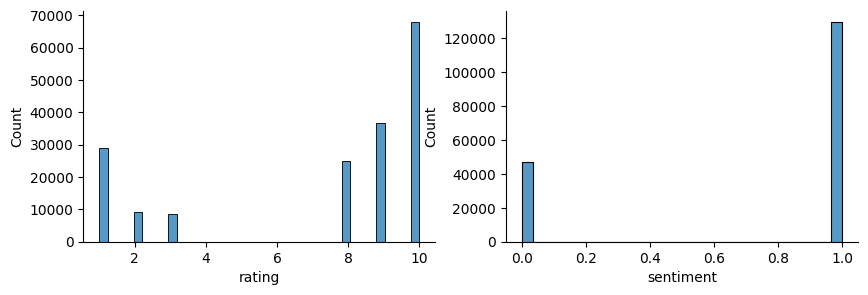

In [9]:
# rating and sentiment histogram after preprocessing
cols = ['rating', 'sentiment']
nrows, ncols = 1, 2

f, axs = plt.subplots(1, 2, figsize=(10,3))
for idx, ax in enumerate(axs):
    sns.histplot(
    data=df,
    stat="count",
    x = cols[idx],
    ax=ax
    )

    # add labels and ticks
    ax.set(xlabel=cols[idx])
    #plt.xticks(np.arange(1,11,1))
    sns.despine()

Our dataset is very imbalanced. We will correct for class imbalance by taking only 46,000 random examples from each class.

In [10]:
# randomly draw 46000 examples from each class
temp_positive = df[df.sentiment.eq(1)].sample(
    n=46000,
    replace=False
)

temp_negative = df[df.sentiment.eq(0)].sample(
    n=46000,
    replace=False
)

df_balanced = pd.concat(
    [temp_positive, temp_negative],
    axis=0)

# shuffle df_balanced
df_balanced.sample(frac=1) # frac=1 retains all the data
df_balanced.reset_index(drop=True, inplace=True) # reset index

print('After preprocessing, our data contains', df_balanced.shape[0], 'reviews.')

After preprocessing, our data contains 92000 reviews.


In [11]:
df_balanced = df_balanced[['review', 'sentiment']]
df_balanced.head(5)

,review,sentiment
0,this medication helps although i have to take...,1
1,i have nerve pain from shingles postherpetic ...,1
2,i suffered with pmdd for over 20 years this i...,1
3,i was diagnosed with pmdd after talking my ne...,1
4,i think the medication does what it 039 s sup...,1


### create TensorFlow dataset

In [12]:
# define target
target = df_balanced.pop('sentiment') # .pop removes sentiment col from df

# target and review combined tensors
data_tf = tf.data.Dataset.from_tensor_slices(
    (df_balanced[['review']].values, target.values)
)

### split data into train, validation, and test partitions

In [13]:
# set random seed
tf.random.set_seed(1)

# define splits for training, validation, test
splits=[0.6, 0.2, 0.2] 

# shuffle data
data_tf = data_tf.shuffle(
    df_balanced.shape[0], reshuffle_each_iteration=False)

data_tf_test = data_tf.take(int(df_balanced.shape[0]*splits[2]))
data_tf_train_valid = data_tf.skip(int(df_balanced.shape[0]*splits[2]))
data_tf_train = data_tf_train_valid.take(int(df_balanced.shape[0]*splits[0]))
data_tf_valid = data_tf_train_valid.skip(int(df_balanced.shape[0]*splits[0]))

In [14]:
# try and except the TF tokenizer
try:
    tokenizer = tfds.features.text.Tokenizer()
except AttributeError:
    tokenizer = tfds.deprecated.text.Tokenizer()

# create an instance of the Counter class
token_counts = Counter()

for example in data_tf_train:
    tokens = tokenizer.tokenize(example[0].numpy()[0])
    token_counts.update(tokens)
    
print('Size of training vocabulary:', len(token_counts))

Size of training vocabulary: 33094


The idea here is to map each unique word (token) in our training vocabulary to a unique integer.

In [15]:
# create an instance of the TF encoder class
try:
    encoder = tfds.features.text.TokenTextEncoder(token_counts) # token_counts contains our training vocabulary
except AttributeError:
    encoder = tfds.deprecated.text.TokenTextEncoder(token_counts)

In [16]:
# the encode_map_fn is defined at the top of the notebook
data_tf_train = data_tf_train.map(encode_map_fn)
data_tf_valid = data_tf_valid.map(encode_map_fn)
data_tf_test = data_tf_test.map(encode_map_fn)

In [17]:
# define batch size
batch_size = 32

# batcing of training, validation and test partitions
train_data = data_tf_train.padded_batch(
    batch_size,
    padded_shapes=([-1],[]))

valid_data = data_tf_valid.padded_batch(
    batch_size,
    padded_shapes=([-1],[]))

test_data = data_tf_test.padded_batch(
    batch_size,
    padded_shapes=([-1],[]))

In [18]:
test_data

<_PaddedBatchDataset element_spec=(TensorSpec(shape=(None, None), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

Note: this is just a stand alone. For clarity, we will code again the Embedding layer in the network architecture.

In [19]:
# Embed our training vocabulary into 10 dimensions.
vocab_size_train = len(token_counts) + 2
embedding_dim = 10

embedding_layer = tf.keras.layers.Embedding(
    vocab_size_train,
    embedding_dim,
)

Let's pass our first example in the training dataset through our embedding layer. The result replaces each integer with the vector from the embedding table:

In [20]:
for example in train_data.take(1):
    print('Seq length of our first training example:', example[0].numpy()[0].shape[0])
    print("Print integers of example:")
    print(example[0].numpy()[0])
    result = embedding_layer(example[0])

print("\nPrint embeddings of example:")
result_df = pd.DataFrame(result[0].numpy())
display(result_df.head())
print("Embedding size:", result_df.shape)

Seq length of our first training example: 158
Print integers of example:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14  1 15  4  5 16 17 18 19 20 21
 22 23 24 25 26 27 28 29 30 31 32 33 12  7 34 35 36 37  9 38 39 40 20 41
 42 35 43 25 44 42 45 46  3  4  5 47 48 49 35  8 50 51 12  2 52 10 53 54
 55 13 56 57  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

Print embeddings of example:


,0,1,2,3,4,5,6,7,8,9
0,0.004331,-0.043532,0.047322,0.005393,-0.048435,0.016896,0.006655,-0.036300,-0.027595,-0.029990
1,-0.040236,-0.032521,0.026008,0.019073,0.007805,0.035878,-0.002897,0.048982,0.038962,-0.007107
2,-0.023277,0.047583,-0.037703,0.010531,0.011370,-0.020657,0.018141,-0.009625,0.035848,-0.020794
3,-0.026343,-0.049911,-0.018325,-0.015448,-0.012127,-0.024202,0.033734,-0.033141,-0.012696,-0.037537
4,0.048194,-0.045778,0.005825,-0.040164,0.023400,0.048086,0.047187,0.012448,-0.018096,-0.002239


Embedding size: (158, 10)


---
## Model

Our objective is to build and train a CNN model to detect if a drug review is positive or negative.

The complete model is made of a few layers:

1. An embedding layer: converts our word tokens (integers) into embedded vectors of a specific size.

2. A few convolutional layers: defined by an input size, number of filters/feature maps to output, and a kernel size. The output of these layers will go through a ReLu activation function and a pooling layer

4. A fully-connected, output layer: maps the convoluted layer outputs to a desired output_size (1 sentiment class).

5. A sigmoid activation layer: turns the output logit into a value 0-1; a class score.


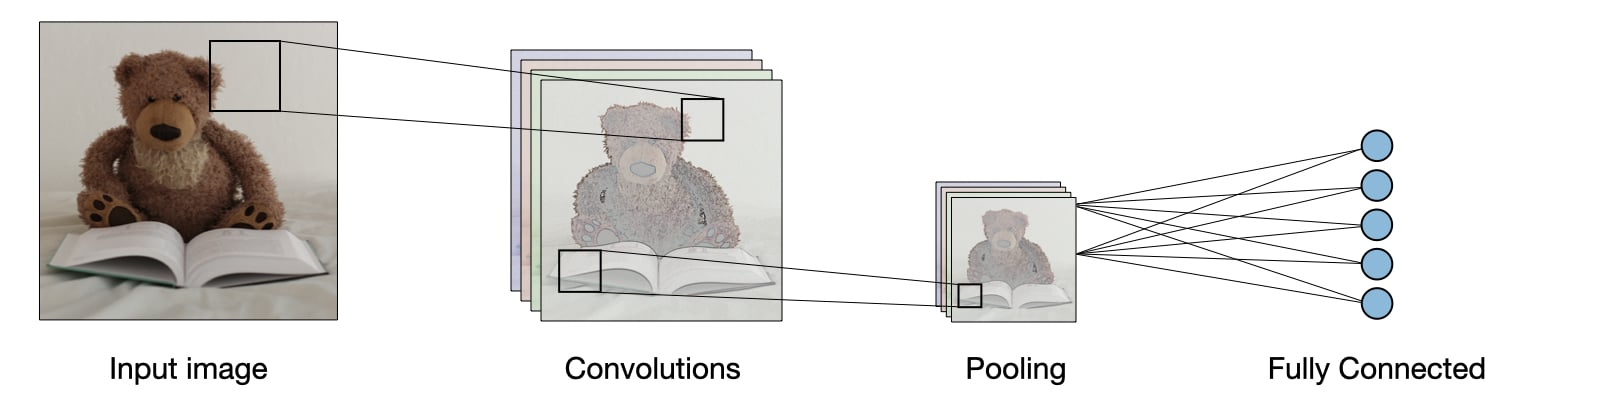


### Build model

Since text data is a sequence of words, we utilize ```1D``` convolutions to scan through the sentences.


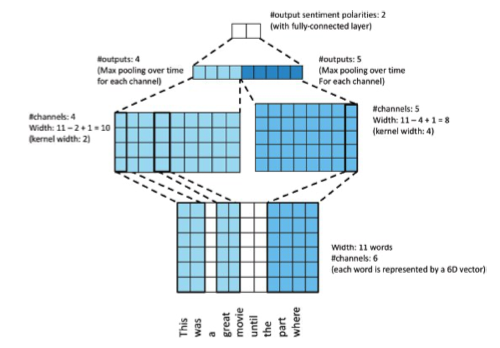

A similar image with more details on how the 1D CNN works for text is shown below [[source]](https://iprathore71.medium.com/neural-network-for-text-processing-95eabc5aaa13):

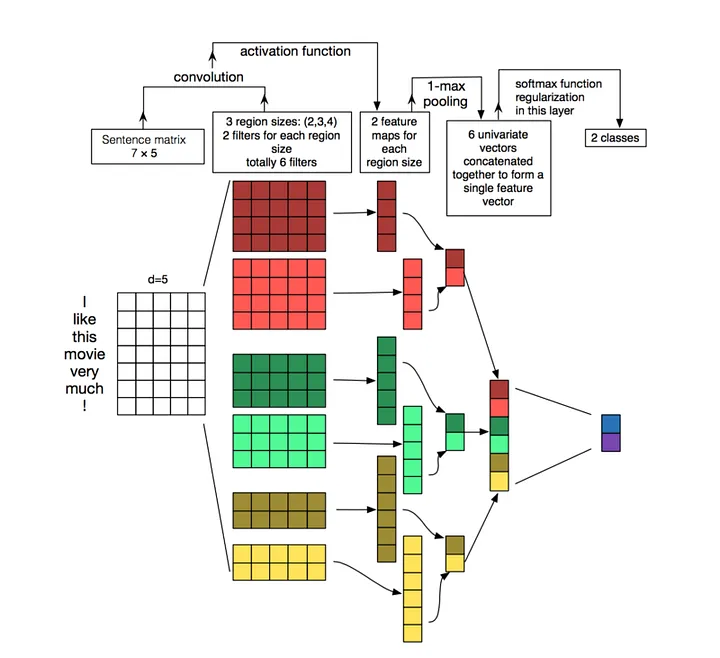


We embed the words using an embedding layer. Then to compute different features, we use 1D kernels of different widths, to capture patterns of different length.  Finally, we use max pooling over time, concatenate the results, and pass to the FC layer.


The kernel size in the convolutional layer defines the number of words to consider as the convolution is passed across the input text, providing a grouping parameter.

Multiple convolutions with different kernel sizes allows a sentence to be processed at different n-grams (groups of words) at a time, whilst the model learns how to best integrate these interpretations.

In [21]:
vocab_size_train = len(token_counts) + 2
embedding_dim = 10

def build_model():
    ''''''
    # clear session and set a random seed for consistent behavior.
    tf.keras.backend.clear_session()
    tf.random.set_seed(1)
    
    # define model
    model = tf.keras.Sequential()

    ## add embedding layer ##
    #########################
    # (this is our input layer)
    # embeddings will be learned during training
    # the weights for the embeddings are randomly initialized (just like any other layer)
    model.add(Embedding(
        vocab_size_train,
        embedding_dim,
        input_length=100, #limits length of sentence to 100 tokens
        name="embedding")
        ),

    ## first convolution ##
    #######################
    model.add(Conv1D(
        filters=128,
        kernel_size=4,
        padding='same',
        activation='relu'))

    # add dropout layer
    model.add(tf.keras.layers.Dropout(
        rate=0.5))

    # add maxpooling
    model.add(MaxPooling1D(pool_size=2))

    ## second convolution ##
    ########################
    model.add(Conv1D(
        filters=64,
        kernel_size=4,
        padding='same',
        activation='relu'))

    # add dropout layer
    model.add(tf.keras.layers.Dropout(
        rate=0.5))

    # add maxpooling
    model.add(MaxPooling1D(pool_size=2))

    ## third convolution ##
    #######################
    model.add(Conv1D(
        filters=32,
        kernel_size=5,
        padding='same',
        activation='relu'))

    # add dropout layer
    model.add(tf.keras.layers.Dropout(
        rate=0.5))

    # add maxpooling
    model.add(MaxPooling1D(pool_size=2))

    ## average embeddings ##
    ########################
    model.add(GlobalAveragePooling1D()),

    # add dropout layer
    model.add(tf.keras.layers.Dropout(
        rate=0.5))



    ## add final dense (output) layer ##
    ####################################
    model.add(Dense(1, activation='sigmoid'))

    # save embeddings before training 
    #embeddings_untrained = model.get_layer('embedding').get_weights()[0]

    # print model summary
    model.summary()
    
    return model


model = build_model()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Compile model

In [22]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

### Fit model

In [23]:
# set random seed to get reproductible results 
# neural network algorithms are stochastic (e.g., due to random weight initialization); setting a random seed helps to get more stable results after each run
# however, best way to deal with randomness is to repeat your experiment many times (30+) and use statistics to summarize the performance of the model
tf.random.set_seed(1)
np.random.seed(1)
history = model.fit(
    train_data, 
    validation_data=valid_data, 
    epochs=5)

Epoch 1/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8012 - loss: 0.4319 - val_accuracy: 0.8755 - val_loss: 0.3621
Epoch 2/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8910 - loss: 0.2839 - val_accuracy: 0.8841 - val_loss: 0.3114
Epoch 3/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9159 - loss: 0.2265 - val_accuracy: 0.8849 - val_loss: 0.3012
Epoch 4/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9321 - loss: 0.1856 - val_accuracy: 0.8838 - val_loss: 0.3065
Epoch 5/5
1725/1725 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9444 - loss: 0.1534 - val_accuracy: 0.8834 - val_loss: 0.3219


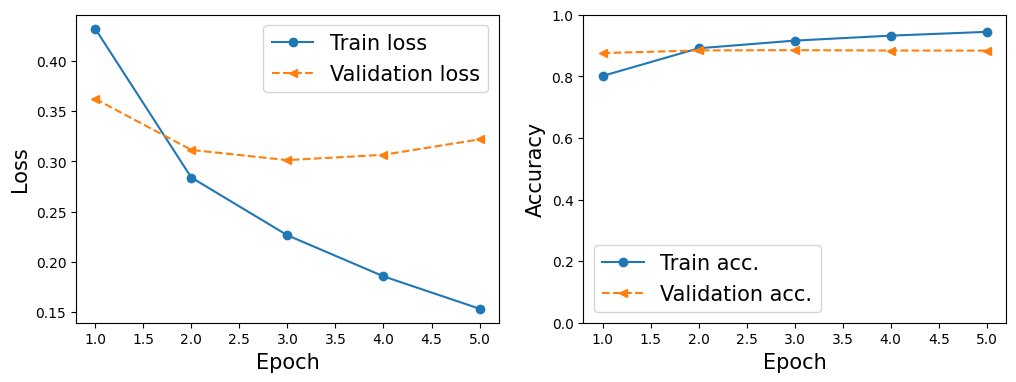

In [24]:
hist = history.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['accuracy'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_accuracy'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
ax.set_ylim(0,1)
plt.show()

In [25]:
print('After training this model for 5 epochs, evaluation on the validation data shows an accuracy of:')
print(np.round(hist['val_accuracy'][-1]*100,2), '%')

After training this model for 5 epochs, evaluation on the validation data shows an accuracy of:
88.34 %


### Evaluation

Let's look at only one example in the test data:

In [26]:
test_results = model.evaluate(test_data)
print('\nTest Acc. {:.2f}%'.format(test_results[1]*100))

575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8859 - loss: 0.3164

Test Acc. 88.59%


In [27]:
# predict probabilities
predictions = model.predict(test_data)

for ex in test_data.take(1):
    print('Printing encoded example:')
    print('-------------------------')
    print(ex[0].numpy()[0]) # test data is a mini-batch, keep only the first example in the first batch
    
    print('\nPrinting decoded example:')
    print('-------------------------')
    print(encoder.decode(ex[0].numpy()[0]))
    
    print('\nPrinting prediction of example:')
    print('-------------------------------')
    if predictions[0] < 0.5:
        print('Negative drug review with probability of positive class:', predictions[0]*100)
    else:
        print('Positive drug review with probability of positive class:', predictions[0]*100)

575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Printing encoded example:
-------------------------
[    1    34   565     7     8    66  9805    59  1461    31 33095  6435
     1   101   234    79    31   300   258    13    56  5734    39    40
    27    35     8    78  2055   129  9085   129  3574    10    34    13
   213    50     1   160   336  1451    38  1096    49    35   287     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0 